# Exploración de Datos: La Tinka
En este notebook exploraremos los datos históricos del archivo `dfrows_tnk.parquet.csv`, buscaremos patrones empezando por características simples (números primos, pares/impares, sumas, gaps), seguido de estadística básica, y finalmente construiremos una función que seleccione combinaciones con mayor probabilidad para el siguiente sorteo en base al histórico y los patrones encontrados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar los datos desde el CSV
df = pd.read_csv('dfrows_tnk.parquet.csv')

# Veamos las primeras filas para entender la estructura
display(df.head())

,fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,b1,b2,b3,b4,b5,b6,gap_b1_b2,gap_b2_b3,gap_b3_b4,gap_b4_b5,gap_b5_b6
0,05/04/2026,1287,10 50 42 14 35 12,47.0,33 01 44,Promoción Sí o Sí,101214354250,10,12,14,35,42,50,2,2,21,7,8
1,01/04/2026,1286,25 23 14 42 37 01,2.0,10 09,Promoción Sí o Sí,11423253742,1,14,23,25,37,42,13,9,2,12,5
2,29/03/2026,1285,07 08 18 39 26 53,37.0,27,Promoción Sí o Sí,70818263953,7,8,18,26,39,53,1,10,8,13,14
3,25/03/2026,1284,14 11 25 08 23 12,18.0,28 30 48 34,Promoción Sí o Sí,81112142325,8,11,12,14,23,25,3,1,2,9,2
4,22/03/2026,1283,07 17 14 46 09 44,34.0,10 06 31 02,Promoción Sí o Sí,70914174446,7,9,14,17,44,46,2,5,3,27,2


## 1. Análisis de Patrones Simples: Primos, Pares, Impares y Sumas
Extraemos la información de las 6 bolillas principales y calculamos métricas simples por sorteo.

In [2]:
bolillas_cols = ['b1', 'b2', 'b3', 'b4', 'b5', 'b6']
all_numbers = df[bolillas_cols].values.flatten()

# Identificamos los números primos posibles (la Tinka actualmente va hasta el 50)
primes = {2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47}

# Calculamos patrones para cada sorteo
df['conteo_primos'] = df[bolillas_cols].apply(lambda row: sum(1 for x in row if x in primes), axis=1)
df['conteo_pares'] = df[bolillas_cols].apply(lambda row: sum(1 for x in row if x % 2 == 0), axis=1)
df['conteo_impares'] = 6 - df['conteo_pares']
df['suma_bolillas'] = df[bolillas_cols].sum(axis=1)

display(df[['sorteo', 'bolillas', 'conteo_primos', 'conteo_pares', 'conteo_impares', 'suma_bolillas']].head(10))

,sorteo,bolillas,conteo_primos,conteo_pares,conteo_impares,suma_bolillas
0,1287,10 50 42 14 35 12,0,5,1,163
1,1286,25 23 14 42 37 01,2,2,4,142
2,1285,07 08 18 39 26 53,1,3,3,151
3,1284,14 11 25 08 23 12,2,3,3,93
4,1283,07 17 14 46 09 44,2,3,3,137
5,1282,16 27 37 48 35 15,1,2,4,178
6,1281,07 08 29 19 04 03,4,2,4,70
7,1280,52 37 32 13 18 06,2,4,2,158
8,1279,49 21 48 14 24 06,0,4,2,162
9,1278,21 28 36 22 24 16,0,5,1,147


/var/folders/sl/1vmdvj_x71d7vcvydhjxp4t80000gn/T/ipykernel_63105/3515833326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='conteo_primos', data=df, ax=axes[0,0], palette='Blues')
/var/folders/sl/1vmdvj_x71d7vcvydhjxp4t80000gn/T/ipykernel_63105/3515833326.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='conteo_pares', data=df, ax=axes[0,1], palette='Greens')


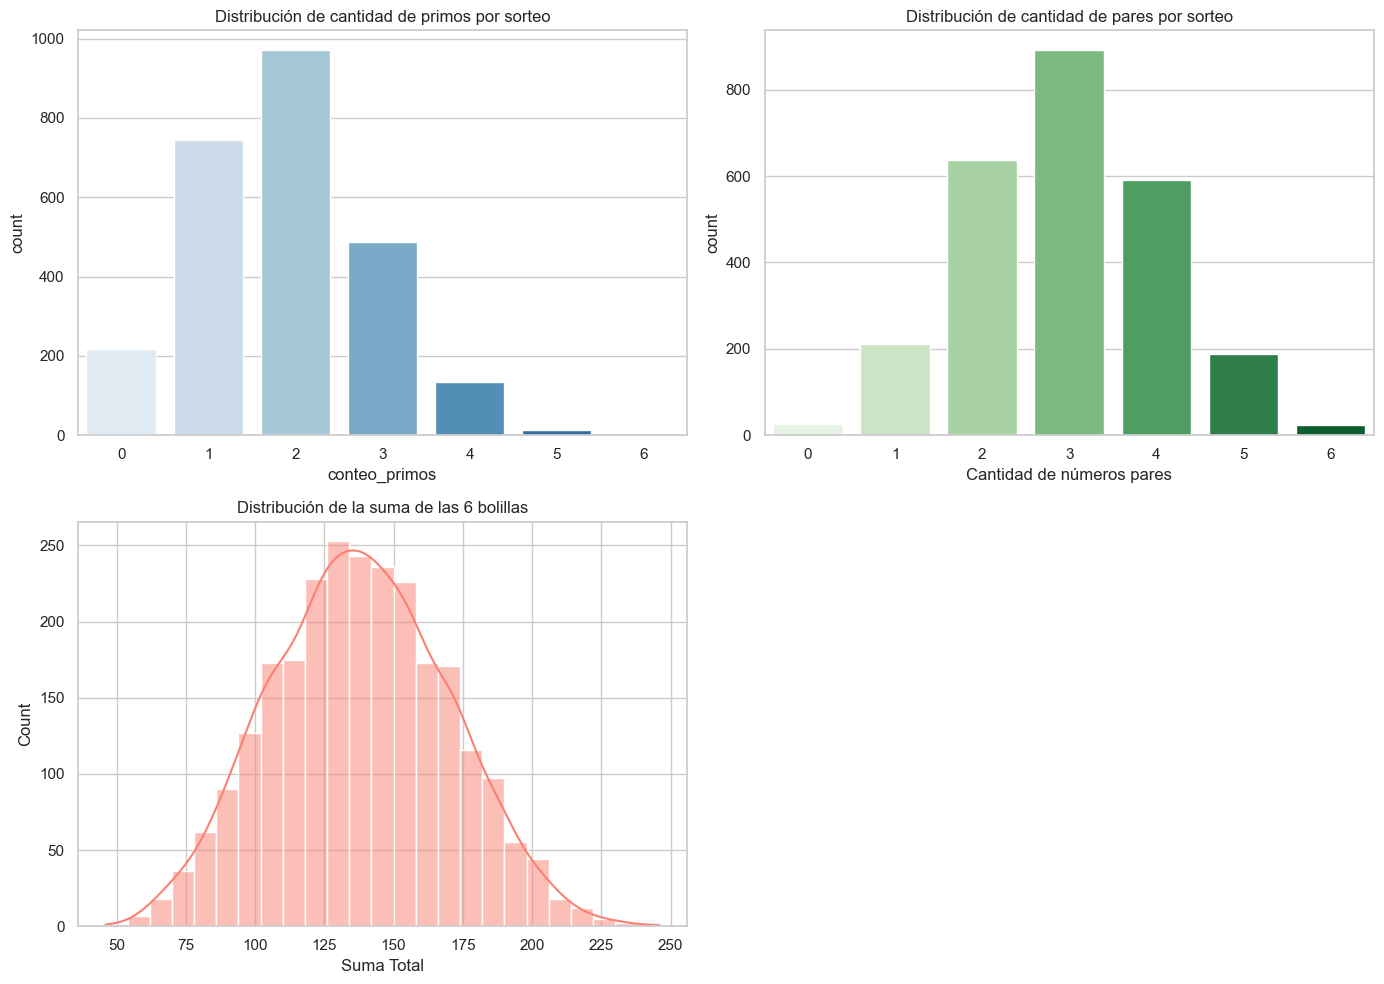

In [3]:
# Visualizamos las distribuciones de estos patrones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='conteo_primos', data=df, ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Distribución de cantidad de primos por sorteo')

sns.countplot(x='conteo_pares', data=df, ax=axes[0,1], palette='Greens')
axes[0,1].set_title('Distribución de cantidad de pares por sorteo')
axes[0,1].set_xlabel('Cantidad de números pares')

sns.histplot(df['suma_bolillas'], bins=25, ax=axes[1,0], color='salmon', kde=True)
axes[1,0].set_title('Distribución de la suma de las 6 bolillas')
axes[1,0].set_xlabel('Suma Total')

fig.delaxes(axes[1,1]) # Ocultar el espacio vacío
plt.tight_layout()
plt.show()

A partir de estos gráficos empezamos a notar patrones:
- Es muy común tener **1 a 3 números primos** por sorteo.
- Las combinaciones suelen tener **2, 3 o 4 números pares**. Combinaciones de puros pares (6) o puros impares (0) son raras.
- La **suma de las bolillas** tiene una distribución normal, centrada aproximadamente entre **100 y 180**.

## 2. Análisis de Gaps (Distancias entre bolillas consecutivas)
El archivo ya contiene los campos de gaps precalculados (`gap_b1_b2`, `gap_b2_b3`, etc.). Veremos su comportamiento.

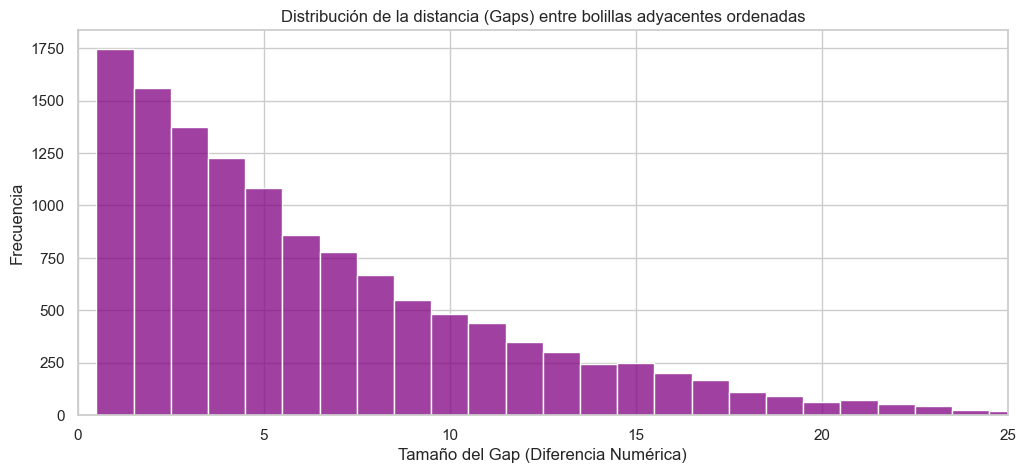

Promedio por posición de Gap:
 gap_b1_b2    6.532503
gap_b2_b3    6.400156
gap_b3_b4    6.502141
gap_b4_b5    6.480343
gap_b5_b6    6.480343
dtype: float64


In [4]:
gap_cols = ['gap_b1_b2', 'gap_b2_b3', 'gap_b3_b4', 'gap_b4_b5', 'gap_b5_b6']
all_gaps = df[gap_cols].values.flatten()

plt.figure(figsize=(12, 5))
sns.histplot(all_gaps[~np.isnan(all_gaps)], bins=range(0, 30), discrete=True, color='purple')
plt.title('Distribución de la distancia (Gaps) entre bolillas adyacentes ordenadas')
plt.xlabel('Tamaño del Gap (Diferencia Numérica)')
plt.ylabel('Frecuencia')
plt.xlim(0, 25)
plt.show()

print("Promedio por posición de Gap:\n", df[gap_cols].mean())

Los Gaps tienden a ser pequeños. Distancias de **1, 2, 3 o 4** son extremadamente comunes, lo que significa que a menudo salen bolillas agrupadas.

## 3. Estadística Básica: Bolillas Frecuentes y Rezagadas
Analizaremos qué números salen más seguido y cuáles han salido menos dentro de todo nuestro dataset histórico.

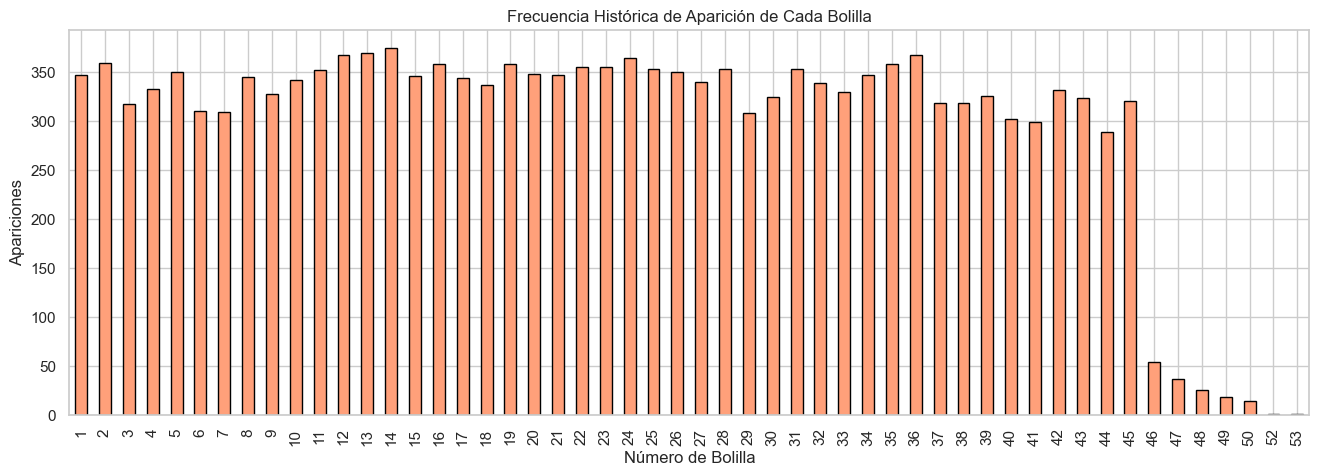

🌟 Top 5 Bolillas MÁS frecuentes:


14    374
13    369
12    367
36    367
24    364
Name: count, dtype: int64


💤 Top 5 Bolillas MENOS frecuentes:


53     1
52     1
50    14
49    18
48    26
Name: count, dtype: int64

In [5]:
frecuencias = pd.Series(all_numbers).value_counts().sort_index()

plt.figure(figsize=(16, 5))
frecuencias.plot(kind='bar', color='#FFA07A', edgecolor='black')
plt.title('Frecuencia Histórica de Aparición de Cada Bolilla')
plt.xlabel('Número de Bolilla')
plt.ylabel('Apariciones')
plt.show()

print("🌟 Top 5 Bolillas MÁS frecuentes:")
display(frecuencias.sort_values(ascending=False).head(5))

print("\n💤 Top 5 Bolillas MENOS frecuentes:")
display(frecuencias.sort_values().head(5))

## 4. Función de Predicción / Generación de Combinaciones Probables
Finalmente, usaremos toda la heurística aprendida de los datos históricos para crear un filtro generador.
El generador:
1. Sorteará números usando las **probabilidades históricas** de cada bolilla (dar mayor chance a las más frecuentes).
2. Validará cada posible intento asegurándose de que la combinación cumpla **patrones normales** (rango de suma, balance de pares/impares).

In [20]:
def generar_combinaciones_probables(df, n_combinaciones=5, random_seed=None):
    """
    Genera combinaciones basadas en la frecuencia histórica ponderada
    y filtros heurísticos de los patrones (Suma, Pares, Gaps).
    """
    if random_seed:
        np.random.seed(random_seed)
        
    # Extraer frecuencias históricas
    bolillas_cols = ['b1', 'b2', 'b3', 'b4', 'b5', 'b6']
    historial = df[bolillas_cols].values.flatten()
    frecuencias = pd.Series(historial).value_counts().sort_index()
    
    # Nos aseguramos de tener hasta el número 50 (Tinka actual)
    for i in range(1, 51):
        if i not in frecuencias:
            frecuencias[i] = 1 # smoothing simple para evitar prob 0
            
    # Crear vector de probabilidades a partir de frecuencias
    pesos = frecuencias.values / frecuencias.values.sum()
    numeros = frecuencias.index.values
    
    combinaciones_validas = []
    intentos = 0
    
    while len(combinaciones_validas) < n_combinaciones:
        intentos += 1
        # Elegir 6 números sin repetición, dándole peso a la frecuencia histórica
        combo = np.random.choice(numeros, size=6, replace=False, p=pesos)
        combo.sort()
        
        # Filtros heurísticos que descubrimos en el EDA:
        suma = combo.sum()
        pares = sum(1 for x in combo if x % 2 == 0)
        
        # 1. Suma debe estar entre 100 y 180 (el grueso de la campana)
        # 2. Cantidad de pares debe ser 2, 3 o 4
        if (100 <= suma <= 180) and (2 <= pares <= 4):
            # 3. Limitar agrupaciones excesivas (conocer patrones de gaps)
            diffs = np.diff(combo)
            # No queremos más de 2 pares de números adyacentes (ej. 1,2 y 14,15)
            consecutivos = sum(1 for d in diffs if d == 1)
            if consecutivos <= 2:
                combinaciones_validas.append(combo)
                
    return combinaciones_validas, intentos

# Generamos 5 opciones con mayores probabilidades teóricas
num_opts = 5
opciones, intentos_totales = generar_combinaciones_probables(df, n_combinaciones=num_opts)

print(f"=== Se evaluaron {intentos_totales} combinaciones para encontrar {num_opts} que cumplan los patrones ===\n")
print("🔮 COMBINACIONES SUGERIDAS PARA EL PRÓXIMO SORTEO 🔮\n")
for i, c in enumerate(opciones, 1):
    suma_c = c.sum()
    pares_c = sum(1 for x in c if x % 2 == 0)
    print(f"Opción {i}: {[str(q) for q in list(c)]} -> (Suma: {suma_c}, Pares: {pares_c}, Impares: {6-pares_c})")

=== Se evaluaron 10 combinaciones para encontrar 5 que cumplan los patrones ===

🔮 COMBINACIONES SUGERIDAS PARA EL PRÓXIMO SORTEO 🔮

Opción 1: ['4', '5', '6', '18', '22', '45'] -> (Suma: 100, Pares: 4, Impares: 2)
Opción 2: ['8', '14', '19', '21', '30', '44'] -> (Suma: 136, Pares: 4, Impares: 2)
Opción 3: ['3', '10', '20', '23', '25', '35'] -> (Suma: 116, Pares: 2, Impares: 4)
Opción 4: ['3', '14', '18', '19', '25', '26'] -> (Suma: 105, Pares: 3, Impares: 3)
Opción 5: ['5', '8', '10', '19', '33', '40'] -> (Suma: 115, Pares: 3, Impares: 3)
